In [1]:
import pandapower as pp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

import grid_plotting as gp
import network_5bus

from network_5bus import create_5bus_network

importlib.reload(gp)
importlib.reload(network_5bus)

<module 'network_5bus' from '/home/agerami/github/python_installation_and_tutorials/tutorials/to_go_further/network_5bus.py'>

In [2]:
net = create_5bus_network()

print(net.bus[["name", "vn_kv"]])
print(net.line[["name", "from_bus", "to_bus"]])
print(net.trafo[["name", "hv_bus", "lv_bus", "sn_mva", "vk_percent"]])
print(net.gen[["name", "bus", "p_mw", "vm_pu"]])
print(net.load[["name", "bus", "p_mw", "q_mvar"]])
print(net.ext_grid[["name", "bus", "vm_pu"]])

    name  vn_kv
0  Bus 1  400.0
1  Bus 2  400.0
2  Bus 3  400.0
3  Bus 4  400.0
4  Bus 5   20.0
     name  from_bus  to_bus
0  Line A         0       1
1  Line B         1       2
2  Line C         0       2
3  Line D         2       3
4  Line E         1       3
  name  hv_bus  lv_bus  sn_mva  vk_percent
0   T1       3       4   200.0        10.0
                 name  bus   p_mw  vm_pu
0  PV Generator Bus 2    1  150.0   1.05
1  PV Generator Bus 5    4  100.0   1.00
         name  bus   p_mw  q_mvar
0  Load Bus 2    1  100.0    20.0
1  Load Bus 3    2  200.0    80.0
        name  bus  vm_pu
0  Slack Bus    0    1.0


In [3]:
pp.runpp(net, calculate_voltage_angles=True)

print("Power flow converged:", net.converged)

pf_bus = net.res_bus.copy()
pf_gen = net.res_gen.copy()
pf_ext_grid = net.res_ext_grid.copy()
pf_line = net.res_line.copy()
pf_trafo = net.res_trafo.copy()

pf_total_gen_p = pf_ext_grid["p_mw"].sum() + pf_gen["p_mw"].sum()
pf_total_load_p = net.load["p_mw"].sum()
pf_line_losses = pf_line["pl_mw"].sum()
pf_trafo_losses = pf_trafo["pl_mw"].sum()
pf_total_losses = pf_line_losses + pf_trafo_losses

print("\nPF bus voltages")
print(pf_bus[["vm_pu", "va_degree", "p_mw", "q_mvar"]].round(4))

print("\nPF generator results")
print("External grid:")
print(pf_ext_grid[["p_mw", "q_mvar"]].round(4))
print("Generators:")
print(pf_gen[["p_mw", "q_mvar", "va_degree", "vm_pu"]].round(4))

print("\nPF losses")
print("Total generation [MW]:", round(pf_total_gen_p, 4))
print("Total load       [MW]:", round(pf_total_load_p, 4))
print("Line losses      [MW]:", round(pf_line_losses, 4))
print("Trafo losses     [MW]:", round(pf_trafo_losses, 4))
print("Total losses     [MW]:", round(pf_total_losses, 4))

Power flow converged: True

PF bus voltages
    vm_pu  va_degree      p_mw   q_mvar
0  1.0000     0.0000  -54.6937  67.9140
1  1.0500     0.2631  -50.0000  41.5295
2  0.9512   -14.2978  200.0000  80.0000
3  1.0138     4.6850    0.0000   0.0000
4  1.0000     7.5119 -100.0000  25.1829

PF generator results
External grid:
      p_mw  q_mvar
0  54.6937 -67.914
Generators:
    p_mw   q_mvar  va_degree  vm_pu
0  150.0 -21.5295     0.2631   1.05
1  100.0 -25.1829     7.5119   1.00

PF losses
Total generation [MW]: 304.6937
Total load       [MW]: 300.0
Line losses      [MW]: 4.6937
Trafo losses     [MW]: -0.0
Total losses     [MW]: 4.6937


 OPF has an objective function, equality constraints, and inequality constraints. The equality constraints are the power-flow equations, and the inequality constraints include voltage limits, generator limits, and line/transformer limits.

In [4]:
# AC OPTIMAL POWER FLOW SETTINGS
# Bus 1 is the slack bus. In OPF, we allow it to generate power within defined limits.
net.ext_grid["controllable"] = True

net.ext_grid["min_p_mw"] = 0.0
net.ext_grid["max_p_mw"] = 500.0

net.ext_grid["min_q_mvar"] = -500.0
net.ext_grid["max_q_mvar"] = 500.0

# Generator controllability
# gen 0: generator at Bus 2
# gen 1: generator at Bus 5

net.gen["controllable"] = True

# Generator at Bus 2
net.gen.loc[0, "min_p_mw"] = 50.0
net.gen.loc[0, "max_p_mw"] = 250.0
net.gen.loc[0, "min_q_mvar"] = -200.0
net.gen.loc[0, "max_q_mvar"] = 200.0

# Generator at Bus 5
net.gen.loc[1, "min_p_mw"] = 20.0
net.gen.loc[1, "max_p_mw"] = 150.0
net.gen.loc[1, "min_q_mvar"] = -100.0
net.gen.loc[1, "max_q_mvar"] = 100.0

# voltage limits
net.bus["min_vm_pu"] = 0.95
net.bus["max_vm_pu"] = 1.05

# Line and transformer loading limits
net.line["max_loading_percent"] = 100.0
net.trafo["max_loading_percent"] = 100.0

We use use quadratic generation costs for objective:

C_i(P_{Gi}) = c_0 +c_1P_{Gi}+c_2P_{Gi}^2
	​


In [5]:
# cost functions

# Generator 1: external grid at Bus 1
pp.create_poly_cost(
    net,
    element=0,
    et="ext_grid",
    cp0_eur=500.0,
    cp1_eur_per_mw=5.3,
    cp2_eur_per_mw2=0.004
)

# Generator 2: generator at Bus 2
pp.create_poly_cost(
    net,
    element=0,
    et="gen",
    cp0_eur=400.0,
    cp1_eur_per_mw=5.5,
    cp2_eur_per_mw2=0.006
)

# Generator 3: generator at Bus 5
pp.create_poly_cost(
    net,
    element=1,
    et="gen",
    cp0_eur=200.0,
    cp1_eur_per_mw=5.8,
    cp2_eur_per_mw2=0.009
)

print(net.poly_cost)

   element        et  cp0_eur  cp1_eur_per_mw  cp2_eur_per_mw2  cq0_eur  \
0        0  ext_grid    500.0             5.3            0.004      0.0   
1        0       gen    400.0             5.5            0.006      0.0   
2        1       gen    200.0             5.8            0.009      0.0   

   cq1_eur_per_mvar  cq2_eur_per_mvar2  
0               0.0                0.0  
1               0.0                0.0  
2               0.0                0.0  


In [6]:
# run AC-OPF
pp.runopp(
    net,
    calculate_voltage_angles=True,
    init="pf"
)

print("OPF converged:", net.OPF_converged)
print("Total OPF cost:", net.res_cost)

OPF converged: True
Total OPF cost: 2934.7947329241683


In [7]:
# OPF results
opf_bus_results = pd.DataFrame({
    "bus": net.bus.index,
    "name": net.bus["name"],
    "vm_pu": net.res_bus["vm_pu"].round(4),
    "va_degree": net.res_bus["va_degree"].round(4),
    "p_mw": net.res_bus["p_mw"].round(4),
    "q_mvar": net.res_bus["q_mvar"].round(4),
})

opf_gen_results = pd.DataFrame({
    "generator": ["G1 Slack Bus", "G2 Bus 2", "G3 Bus 5"],
    "bus": [
        int(net.ext_grid.loc[0, "bus"]),
        int(net.gen.loc[0, "bus"]),
        int(net.gen.loc[1, "bus"]),
    ],
    "p_mw": [
        net.res_ext_grid.loc[0, "p_mw"],
        net.res_gen.loc[0, "p_mw"],
        net.res_gen.loc[1, "p_mw"],
    ],
    "q_mvar": [
        net.res_ext_grid.loc[0, "q_mvar"],
        net.res_gen.loc[0, "q_mvar"],
        net.res_gen.loc[1, "q_mvar"],
    ],
})

opf_gen_results["p_mw"] = opf_gen_results["p_mw"].round(4)
opf_gen_results["q_mvar"] = opf_gen_results["q_mvar"].round(4)

opf_line_results = net.res_line[[
    "p_from_mw", "q_from_mvar", "p_to_mw", "q_to_mvar",
    "pl_mw", "ql_mvar", "loading_percent"
]].round(4)

opf_trafo_results = net.res_trafo[[
    "p_hv_mw", "q_hv_mvar", "p_lv_mw", "q_lv_mvar",
    "pl_mw", "ql_mvar", "loading_percent"
]].round(4)

print("\nOPF bus results")
print(opf_bus_results.to_string(index=False))

print("\nOPF generator dispatch")
print(opf_gen_results.to_string(index=False))

print("\nOPF line results")
print(opf_line_results)

print("\nOPF transformer results")
print(opf_trafo_results)


OPF bus results
 bus  name  vm_pu  va_degree      p_mw  q_mvar
   0 Bus 1 1.0500     0.0000 -157.0511 43.2206
   1 Bus 2 1.0500    -6.9923    0.4968 82.0539
   2 Bus 3 0.9951   -19.9044  200.0000 80.0000
   3 Bus 4 1.0500    -8.3068    0.0000  0.0000
   4 Bus 5 1.0364    -7.0511  -47.6930 27.6413

OPF generator dispatch
   generator  bus     p_mw   q_mvar
G1 Slack Bus    0 157.0511 -43.2206
    G2 Bus 2    1  99.5032 -62.0539
    G3 Bus 5    4  47.6930 -27.6413

OPF line results
   p_from_mw  q_from_mvar  p_to_mw  q_to_mvar   pl_mw  ql_mvar  \
0    66.8468     -46.6766 -66.0349   -33.4025  0.8118 -80.0791   
1    59.2706     -26.0490 -58.5742   -43.7290  0.6964 -69.7781   
2    90.2043       3.4560 -88.6102   -13.4276  1.5941  -9.9716   
3   -52.8156     -22.8434  53.9462    -7.7039  1.1306 -30.5473   
4     6.2676     -22.6024  -6.2532   -21.3519  0.0144 -43.9543   

   loading_percent  
0          11.2076  
1          10.6027  
2          12.9996  
3           8.3467  
4           3

In [8]:
comparison_voltage = pd.DataFrame({
    "bus": net.bus.index,
    "name": net.bus["name"],
    "Vm_PF": pf_bus["vm_pu"].round(4),
    "Vm_OPF": net.res_bus["vm_pu"].round(4),
    "dVm": (net.res_bus["vm_pu"] - pf_bus["vm_pu"]).round(5),
    "Va_PF": pf_bus["va_degree"].round(4),
    "Va_OPF": net.res_bus["va_degree"].round(4),
    "dVa": (net.res_bus["va_degree"] - pf_bus["va_degree"]).round(5),
})

comparison_dispatch = pd.DataFrame({
    "generator": ["G1 Slack Bus", "G2 Bus 2", "G3 Bus 5"],
    "P_PF_MW": [
        pf_ext_grid.loc[0, "p_mw"],
        pf_gen.loc[0, "p_mw"],
        pf_gen.loc[1, "p_mw"],
    ],
    "P_OPF_MW": [
        net.res_ext_grid.loc[0, "p_mw"],
        net.res_gen.loc[0, "p_mw"],
        net.res_gen.loc[1, "p_mw"],
    ],
    "Q_PF_Mvar": [
        pf_ext_grid.loc[0, "q_mvar"],
        pf_gen.loc[0, "q_mvar"],
        pf_gen.loc[1, "q_mvar"],
    ],
    "Q_OPF_Mvar": [
        net.res_ext_grid.loc[0, "q_mvar"],
        net.res_gen.loc[0, "q_mvar"],
        net.res_gen.loc[1, "q_mvar"],
    ],
})

comparison_dispatch = comparison_dispatch.round(4)

opf_total_gen_p = (
    net.res_ext_grid["p_mw"].sum()
    + net.res_gen["p_mw"].sum()
)

opf_total_losses = (
    net.res_line["pl_mw"].sum()
    + net.res_trafo["pl_mw"].sum()
)

comparison_losses = pd.DataFrame({
    "case": ["Normal PF", "AC-OPF"],
    "total_generation_mw": [pf_total_gen_p, opf_total_gen_p],
    "total_load_mw": [pf_total_load_p, net.load["p_mw"].sum()],
    "total_losses_mw": [pf_total_losses, opf_total_losses],
}).round(4)

print("\nVoltage comparison: PF vs OPF")
print(comparison_voltage.to_string(index=False))

print("\nGenerator dispatch comparison: PF vs OPF")
print(comparison_dispatch.to_string(index=False))

print("\nLoss comparison")
print(comparison_losses.to_string(index=False))


Voltage comparison: PF vs OPF
 bus  name  Vm_PF  Vm_OPF      dVm    Va_PF   Va_OPF       dVa
   0 Bus 1 1.0000  1.0500  0.04999   0.0000   0.0000   0.00000
   1 Bus 2 1.0500  1.0500 -0.00002   0.2631  -6.9923  -7.25539
   2 Bus 3 0.9512  0.9951  0.04392 -14.2978 -19.9044  -5.60661
   3 Bus 4 1.0138  1.0500  0.03615   4.6850  -8.3068 -12.99185
   4 Bus 5 1.0000  1.0364  0.03639   7.5119  -7.0511 -14.56303

Generator dispatch comparison: PF vs OPF
   generator  P_PF_MW  P_OPF_MW  Q_PF_Mvar  Q_OPF_Mvar
G1 Slack Bus  54.6937  157.0511   -67.9140    -43.2206
    G2 Bus 2 150.0000   99.5032   -21.5295    -62.0539
    G3 Bus 5 100.0000   47.6930   -25.1829    -27.6413

Loss comparison
     case  total_generation_mw  total_load_mw  total_losses_mw
Normal PF             304.6937          300.0           4.6937
   AC-OPF             304.2473          300.0           4.2473


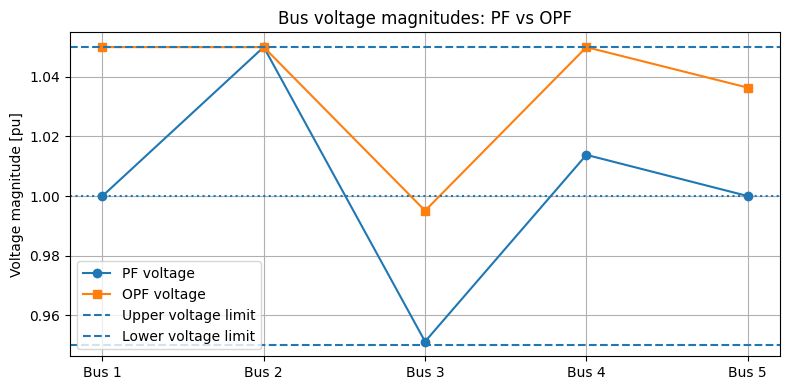

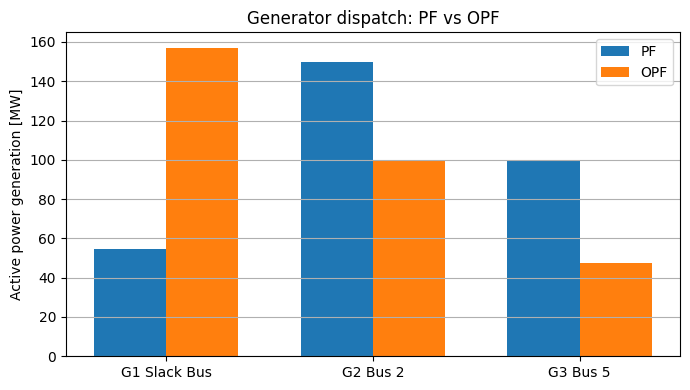

In [10]:
bus_names = net.bus["name"].tolist()

plt.figure(figsize=(8, 4))
plt.plot(bus_names, pf_bus["vm_pu"], marker="o", label="PF voltage")
plt.plot(bus_names, net.res_bus["vm_pu"], marker="s", label="OPF voltage")
plt.axhline(1.05, linestyle="--", label="Upper voltage limit")
plt.axhline(0.95, linestyle="--", label="Lower voltage limit")
plt.axhline(1.00, linestyle=":")
plt.ylabel("Voltage magnitude [pu]")
plt.title("Bus voltage magnitudes: PF vs OPF")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
x = np.arange(len(comparison_dispatch))
width = 0.35

plt.bar(x - width/2, comparison_dispatch["P_PF_MW"], width, label="PF")
plt.bar(x + width/2, comparison_dispatch["P_OPF_MW"], width, label="OPF")

plt.xticks(x, comparison_dispatch["generator"])
plt.ylabel("Active power generation [MW]")
plt.title("Generator dispatch: PF vs OPF")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()